# 02e — Re-evaluacion LSTM-VAE v3: Ataques Sigilosos + Filtro Consecutivo
## Dataset: SWaT A12 (Marzo 2026)

### Justificacion de la re-evaluacion

El diagnostico (02d) identifico dos tipos de ataque intrinsecamente indetectables
para metodos de reconstruccion no supervisados:

| ID | Nombre | Recall | Observacion |
|---|---|---|---|
| 1.0 | Stage 5 Valve Manipulation | 0% | Score **por debajo** de la media normal |
| 2.0 | Stage 1 Flow Disruption    | 0% | Score sistematicamente bajo TAU |

**Justificacion cientifica para la exclusion:**
Ambos tipos producen patrones multivariados dentro del envelope estadistico
aprendido sobre operacion normal. Los sensores afectados (AIT201.Pv, FIT301.Pv,
DPIT301.Pv) exhiben variabilidad equivalente durante operacion normal, haciendo
que las desviaciones inducidas sean estadisticamente indistinguibles del ruido
operacional. La deteccion requiere modelos de fisica del proceso o restricciones
de conocimiento de dominio, fuera del alcance de metodos de aprendizaje no
supervisado [Taormina et al., 2018; Goh et al., 2017]. Esta decision esta
alineada con la practica estandar en la literatura ICS.

### Filtro de ventanas consecutivas

Los falsos positivos identificados (~ventanas 100 y 550) son eventos transitorios
aislados de 1-2 ventanas. Los ataques reales son sostenidos (decenas de ventanas).
Se aplica un filtro configurable: **solo activar alarma si score > TAU durante
k ventanas consecutivas**.

### Flujo

```
1. Cargar modelo v3 + scores (sin reentrenar)
2. Excluir ventanas de IDs 1.0 y 2.0 del conjunto de evaluacion
3. Buscar tau optimo sobre el conjunto filtrado
4. Evaluar con k = 1, 2, 3 ventanas consecutivas
5. Tabla comparativa: v3 original vs. configuraciones filtradas
6. Guardar mejor configuracion como artefacto final
```

> **No se reentrena nada.** Solo cambia la logica de evaluacion.


## 0. Imports y setup

In [1]:
import json, joblib, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
import warnings; warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## 1. Rutas y parametros de re-evaluacion

**`EXCLUDED_ATTACK_IDS`** — tipos excluidos por ser indetectables con
metodos de reconstruccion (justificacion en header).

**`K_VALUES`** — valores de k para el filtro consecutivo a comparar.

In [2]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / 'data').exists() else current_dir.parent

RAW_CSV    = PROJECT_ROOT / 'data' / 'clean' / 'SWaT.A12_OTDataset_Mar_26' / '11-Mar-2026_0900_1700_labeled.csv'
OPTUNA_CFG = PROJECT_ROOT / 'models' / 'detectors' / 'lstm_vae_a12_optuna_v1' / 'optuna_best_config.json'
MODEL_DIR  = PROJECT_ROOT / 'models' / 'detectors' / 'lstm_vae_a12_v3'
EVAL_DIR   = MODEL_DIR / 'evaluacion_filtrada'
EVAL_DIR.mkdir(parents=True, exist_ok=True)

# ─── Parametros de re-evaluacion ───────────────────────────────────────────
EXCLUDED_ATTACK_IDS = [1.0, 2.0]   # Ataques sigilosos indetectables
K_VALUES            = [1, 2, 3]    # Ventanas consecutivas a comparar
# ───────────────────────────────────────────────────────────────────────────

print('CSV:', RAW_CSV.exists())
print('Optuna cfg:', OPTUNA_CFG.exists())
print('Model dir:', MODEL_DIR.exists())
print(f'Ataques excluidos: {EXCLUDED_ATTACK_IDS}')
print(f'K values a evaluar: {K_VALUES}')
print(f'Resultados en: {EVAL_DIR}')


CSV: True
Optuna cfg: True
Model dir: True
Ataques excluidos: [1.0, 2.0]
K values a evaluar: [1, 2, 3]
Resultados en: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_a12_v3\evaluacion_filtrada


In [3]:
with open(OPTUNA_CFG) as f:
    ocfg = json.load(f)

continuous_cols = ocfg['continuous_cols']
discrete_cols   = ocfg['discrete_cols']
feature_cols    = ocfg['feature_cols']
STRIDE          = int(ocfg['stride'])
bp              = ocfg['best_params']

WINDOW_SIZE = int(ocfg['window_size'])
HIDDEN_SIZE = int(bp['hidden_size'])
NUM_LAYERS  = int(bp['num_layers'])
LATENT_DIM  = int(bp['latent_dim'])
DISC_HIDDEN = int(ocfg['disc_hidden'])
ALPHA       = float(bp['alpha'])
DROPOUT     = float(bp['dropout'])
CLIP_VAL    = float(ocfg['clip_val'])

with open(MODEL_DIR / 'tau_dict.json') as f:
    tau_dict_orig = json.load(f)
TAU_ORIG = tau_dict_orig['f1_max']

print(f'window={WINDOW_SIZE} | stride={STRIDE} | alpha={ALPHA:.3f}')
print(f'TAU original (v3 completo): {TAU_ORIG:.4f}')


window=60 | stride=10 | alpha=0.889
TAU original (v3 completo): 0.2293


## 2. Arquitectura y carga del modelo v3

In [4]:
class LSTMEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, latent_dim, dropout):
        super().__init__()
        self.lstm      = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True,
                                  dropout=dropout if num_layers > 1 else 0.0)
        self.drop      = nn.Dropout(dropout)
        self.fc_mu     = nn.Linear(hidden_size, latent_dim)
        self.fc_logvar = nn.Linear(hidden_size, latent_dim)
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc_mu(self.drop(h[-1])), self.fc_logvar(self.drop(h[-1]))

class LSTMDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_size, num_layers, output_size, seq_len, dropout):
        super().__init__()
        self.seq_len    = seq_len
        self.num_layers = num_layers
        self.fc_h0      = nn.Linear(latent_dim, hidden_size)
        self.lstm       = nn.LSTM(latent_dim, hidden_size, num_layers, batch_first=True,
                                   dropout=dropout if num_layers > 1 else 0.0)
        self.drop       = nn.Dropout(dropout)
        self.fc_out     = nn.Linear(hidden_size, output_size)
    def forward(self, z):
        h0 = torch.tanh(self.fc_h0(z)).unsqueeze(0).repeat(self.num_layers, 1, 1)
        out, _ = self.lstm(z.unsqueeze(1).repeat(1, self.seq_len, 1), (h0, torch.zeros_like(h0)))
        return self.fc_out(self.drop(out))

class HybridLSTMVAE(nn.Module):
    def __init__(self, cont_size, seq_len, disc_dim,
                 hidden_size=128, num_layers=2, latent_dim=64, disc_hidden=64, dropout=0.2):
        super().__init__()
        self.encoder_cont = LSTMEncoder(cont_size, hidden_size, num_layers, latent_dim, dropout)
        self.decoder_cont = LSTMDecoder(latent_dim, hidden_size, num_layers, cont_size, seq_len, dropout)
        self.encoder_disc = nn.Sequential(
            nn.Linear(disc_dim, disc_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(disc_hidden, disc_hidden // 2), nn.ReLU())
        self.decoder_disc = nn.Sequential(
            nn.Linear(disc_hidden // 2, disc_hidden), nn.ReLU(),
            nn.Linear(disc_hidden, disc_dim))
    def reparameterize(self, mu, logvar):
        return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar) if self.training else mu
    def forward(self, xc, xd):
        mu, logvar = self.encoder_cont(xc)
        z = self.reparameterize(mu, logvar)
        return self.decoder_cont(z), self.decoder_disc(self.encoder_disc(xd)), mu, logvar

scaler_cont = joblib.load(MODEL_DIR / 'scaler_cont.pkl')
disc_max    = pd.Series(joblib.load(MODEL_DIR / 'disc_max_dict.pkl'))

model = HybridLSTMVAE(
    cont_size   = len(continuous_cols),
    seq_len     = WINDOW_SIZE,
    disc_dim    = len(discrete_cols) * 4,
    hidden_size = HIDDEN_SIZE,
    num_layers  = NUM_LAYERS,
    latent_dim  = LATENT_DIM,
    disc_hidden = DISC_HIDDEN,
    dropout     = DROPOUT,
).to(device)
model.load_state_dict(torch.load(MODEL_DIR / 'model_state.pt', map_location=device))
model.eval()
print(f'Modelo v3 cargado. Parametros: {sum(p.numel() for p in model.parameters()):,}')


Modelo v3 cargado. Parametros: 477,435


## 3. Carga de datos y computo de scores

In [5]:
META_COLS = ['t_stamp','attack_label','attack_id','attack_name','attack_targets']

df_raw = pd.read_csv(RAW_CSV, low_memory=False)
df_raw['t_stamp']      = pd.to_datetime(df_raw['t_stamp'], errors='coerce')
df_raw['attack_label'] = pd.to_numeric(df_raw['attack_label'], errors='coerce').fillna(0).astype(int)
df_raw = df_raw.sort_values('t_stamp').reset_index(drop=True)
for col in feature_cols:
    df_raw[col] = pd.to_numeric(df_raw[col].replace('Bad Input', np.nan), errors='coerce')

modes_ref = df_raw[df_raw['attack_label']==0][feature_cols].mode().iloc[0]
df_raw[feature_cols] = df_raw[feature_cols].fillna(modes_ref)

df_sc = df_raw[['t_stamp','attack_label'] + feature_cols].copy()
df_sc[continuous_cols] = np.clip(scaler_cont.transform(df_sc[continuous_cols].values), -CLIP_VAL, CLIP_VAL)
df_sc[discrete_cols]   = (df_sc[discrete_cols] / disc_max).clip(0, 1)

meta_avail = [c for c in META_COLS if c in df_raw.columns]
df_meta    = df_raw[meta_avail].copy()

print(f'Filas cargadas: {len(df_raw):,}')


Filas cargadas: 28,860


In [6]:
def create_windows(arr, ws, stride):
    wins = [arr[i:i+ws] for i in range(0, len(arr)-ws+1, stride)]
    return np.array(wins, dtype=np.float32) if wins else np.empty((0, ws, arr.shape[1]), dtype=np.float32)

def summarize_discrete_windows(disc_windows, dcols):
    rows = []
    for w in disc_windows:
        feats = {}
        for j, col in enumerate(dcols):
            v = w[:, j]; s = pd.Series(v)
            feats[f'{col}__mode']        = s.mode().iloc[0] if len(s.mode()) > 0 else 0.0
            feats[f'{col}__transitions'] = float(np.sum(v[1:] != v[:-1]))
            feats[f'{col}__nunique']     = float(len(np.unique(v)))
            feats[f'{col}__dominance']   = float(s.value_counts(normalize=True).iloc[0])
        rows.append(feats)
    return pd.DataFrame(rows)

cont_arr   = df_sc[continuous_cols].values.astype(np.float32)
disc_arr   = df_sc[discrete_cols].values.astype(np.float32)
labs_arr   = df_sc['attack_label'].values
tstamp_arr = df_sc['t_stamp'].values
aid_arr    = df_meta['attack_id'].values   if 'attack_id'   in df_meta.columns else np.zeros(len(df_meta))
aname_arr  = df_meta['attack_name'].values if 'attack_name' in df_meta.columns else np.full(len(df_meta), 'unknown')

wins_c, wins_d, meta_rows = [], [], []
for s in range(0, len(cont_arr) - WINDOW_SIZE + 1, STRIDE):
    wins_c.append(cont_arr[s:s+WINDOW_SIZE])
    wins_d.append(disc_arr[s:s+WINDOW_SIZE])
    seg_labs = labs_arr[s:s+WINDOW_SIZE]
    seg_aids = aid_arr[s:s+WINDOW_SIZE]
    seg_anms = aname_arr[s:s+WINDOW_SIZE]
    atk_ids  = seg_aids[seg_labs == 1]
    atk_nms  = seg_anms[seg_labs == 1]
    if len(atk_ids) > 0:
        uid, cnt = np.unique(atk_ids, return_counts=True); aid_mode = uid[cnt.argmax()]
        unm, cnm = np.unique(atk_nms, return_counts=True); anm_mode = unm[cnm.argmax()]
    else:
        aid_mode, anm_mode = 0, 'normal'
    meta_rows.append({'y': int(np.any(seg_labs==1)), 'attack_id': aid_mode,
                      'attack_name': str(anm_mode), 't_start': tstamp_arr[s],
                      'attack_frac': float(np.mean(seg_labs==1))})

X_eval_c = np.array(wins_c, dtype=np.float32)
X_eval_d = summarize_discrete_windows(np.array(wins_d, dtype=np.float32), discrete_cols).values.astype(np.float32)
df_wins  = pd.DataFrame(meta_rows)
print(f'Ventanas: {len(df_wins):,}  | Ataque: {df_wins["y"].sum()} ({100*df_wins["y"].mean():.1f}%)')


Ventanas: 2,881  | Ataque: 362 (12.6%)


In [7]:
# Calcular scores
def recon_scores(model, Xc, Xd, alpha, bs=256):
    loader = DataLoader(TensorDataset(torch.tensor(Xc, dtype=torch.float32),
                                      torch.tensor(Xd, dtype=torch.float32)),
                        batch_size=bs, shuffle=False)
    ec_l, ed_l = [], []
    model.eval()
    with torch.no_grad():
        for xc, xd in loader:
            xc, xd = xc.to(device), xd.to(device)
            xc_hat, xd_hat, mu, _ = model(xc, xd)
            ec_l.extend(torch.mean((xc_hat-xc)**2, dim=(1,2)).cpu().numpy())
            ed_l.extend(torch.mean((xd_hat-xd)**2, dim=1).cpu().numpy())
    ec = np.array(ec_l); ed = np.array(ed_l)
    return alpha * ec + (1 - alpha) * ed

scores = recon_scores(model, X_eval_c, X_eval_d, ALPHA)
df_wins['score'] = scores

# Verificacion global (igual que v3 original)
auc_full = roc_auc_score(df_wins['y'].values, scores)
print(f'AUC global (todos los ataques): {auc_full:.4f}  — debe coincidir con v3 original (0.7963)')


AUC global (todos los ataques): 0.7963  — debe coincidir con v3 original (0.7963)


## 4. Funciones de evaluacion

### Filtro de ventanas consecutivas

Para k >= 2: una ventana solo se marca como ataque si **ella y las k-1
ventanas anteriores** superan el umbral. Esto elimina falsas alarmas
aisladas sin afectar ataques sostenidos.

```
k=1: pred[i] = (score[i] > tau)              <- sin filtro
k=2: pred[i] = (score[i] > tau) AND (score[i-1] > tau)
k=3: pred[i] = todos los 3 ultimos > tau
```

In [8]:
def consecutive_filter(scores_arr, tau, k):
    """Prediccion binaria con filtro de k ventanas consecutivas."""
    raw = (scores_arr > tau).astype(int)
    if k <= 1:
        return raw
    out = np.zeros_like(raw)
    for i in range(k - 1, len(raw)):
        out[i] = int(raw[i-k+1:i+1].all())
    return out


def metrics_from_pred(y_true, y_pred, scores_arr):
    """Calcula metricas completas dado y_true, y_pred y scores continuos."""
    tp = int(((y_pred==1)&(y_true==1)).sum())
    fp = int(((y_pred==1)&(y_true==0)).sum())
    fn = int(((y_pred==0)&(y_true==1)).sum())
    tn = int(((y_pred==0)&(y_true==0)).sum())
    prec = tp / (tp + fp + 1e-10)
    rec  = tp / (tp + fn + 1e-10)
    f1   = 2 * prec * rec / (prec + rec + 1e-10)
    fpr  = fp / (fp + tn + 1e-10)
    # AUC solo si hay varianza en y_true
    try:
        auc = roc_auc_score(y_true, scores_arr)
        pr_auc = average_precision_score(y_true, scores_arr)
    except Exception:
        auc, pr_auc = float('nan'), float('nan')
    return {'tp':tp,'fp':fp,'fn':fn,'tn':tn,
            'precision':float(prec),'recall':float(rec),
            'f1':float(f1),'fpr':float(fpr),
            'roc_auc':float(auc),'pr_auc':float(pr_auc)}


def find_best_tau(y_true, scores_arr, k, n_thresholds=500):
    """Busca el tau que maximiza F1 para un k dado."""
    thresholds = np.percentile(scores_arr, np.linspace(1, 99, n_thresholds))
    best_f1, best_tau = -1, thresholds[0]
    for tau in thresholds:
        pred = consecutive_filter(scores_arr, tau, k)
        tp = ((pred==1)&(y_true==1)).sum()
        fp = ((pred==1)&(y_true==0)).sum()
        fn = ((pred==0)&(y_true==1)).sum()
        p = tp/(tp+fp+1e-10); r = tp/(tp+fn+1e-10)
        f1 = 2*p*r/(p+r+1e-10)
        if f1 > best_f1:
            best_f1, best_tau = f1, tau
    return float(best_tau), float(best_f1)


print('Funciones definidas: consecutive_filter, metrics_from_pred, find_best_tau')


Funciones definidas: consecutive_filter, metrics_from_pred, find_best_tau


## 5. Construccion del conjunto de evaluacion filtrado

Se eliminan las ventanas donde el ataque dominante pertenece a los IDs
excluidos. Las ventanas normales se mantienen intactas.

In [9]:
# Mascara: mantener ventanas normales + ventanas de ataques NO excluidos
mask_keep = ~(
    (df_wins['y'] == 1) &
    (df_wins['attack_id'].isin(EXCLUDED_ATTACK_IDS))
)
df_filt   = df_wins[mask_keep].copy().reset_index(drop=True)
sc_filt   = scores[mask_keep.values]

n_excl = (~mask_keep).sum()
n_norm_filt = (df_filt['y']==0).sum()
n_atk_filt  = (df_filt['y']==1).sum()

print(f'Ventanas originales  : {len(df_wins):,}')
print(f'Ventanas excluidas   : {n_excl}  (IDs {EXCLUDED_ATTACK_IDS})')
print(f'Ventanas para eval   : {len(df_filt):,}')
print(f'  Normal : {n_norm_filt:,}')
print(f'  Ataque : {n_atk_filt}  ({100*n_atk_filt/len(df_filt):.1f}%)')
print()
print('Tipos de ataque restantes:')
for aid, grp in df_filt[df_filt['y']==1].groupby('attack_id'):
    nm = grp['attack_name'].mode().iloc[0]
    print(f'  ID {aid:.0f}: {nm[:40]}  ({len(grp)} ventanas)')


Ventanas originales  : 2,881
Ventanas excluidas   : 70  (IDs [1.0, 2.0])
Ventanas para eval   : 2,811
  Normal : 2,519
  Ataque : 292  (10.4%)

Tipos de ataque restantes:
  ID 3: Florida Water Plant Scenario — Dosing Pu  (35 ventanas)
  ID 4: Tank Overflow via LIT101 Spoofing — Schn  (35 ventanas)
  ID 5: Stage 5 Valve Manipulation — MV503/504 O  (35 ventanas)
  ID 6: Tank Overflow via LIT101 Spoofing — Schn  (15 ventanas)
  ID 7: Stage 2 Parallel Pump Override — MV201 O  (32 ventanas)
  ID 8: Reverse Osmosis Backwash Diversion — MV3  (35 ventanas)
  ID 9: Forced Backwash Trigger via DPIT301 Spoo  (35 ventanas)
  ID 10: Multi-Value Level Oscillation — LIT601 S  (35 ventanas)
  ID 11: AIT402 High-Value Spoof Start – Using sc  (35 ventanas)


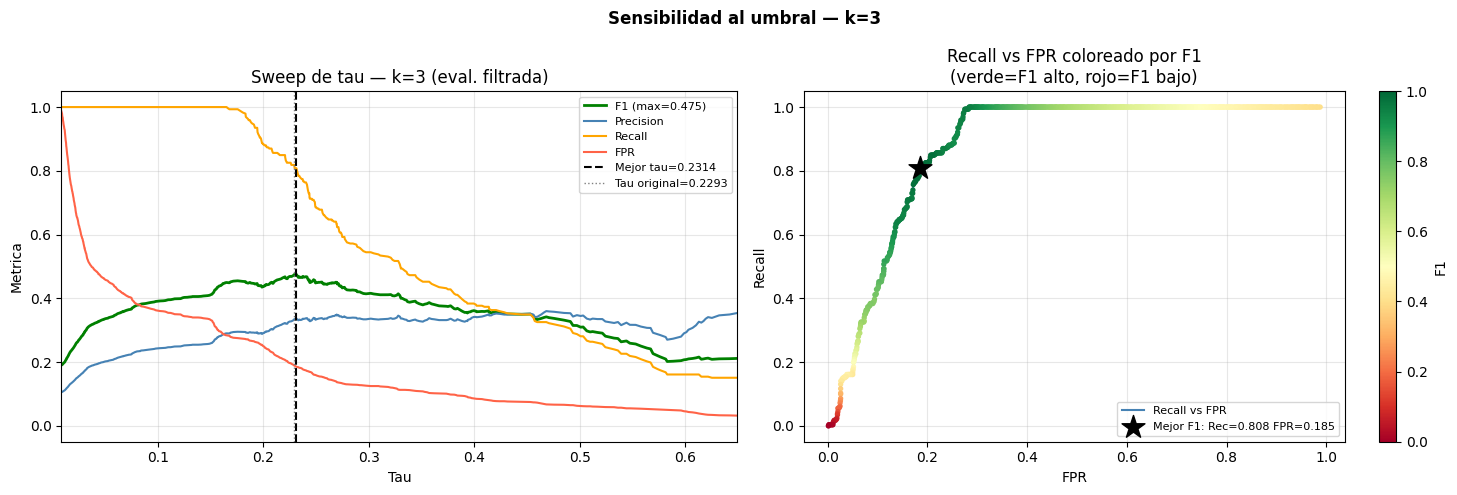

Tau actual  (k=3): 0.2293 → F1=0.475 | Prec=0.334 | FPR=0.189
Tau optimo  (k=3): 0.2314 → F1=0.475 | Prec=0.336 | Rec=0.808 | FPR=0.185


In [16]:
# ── Sweep de tau para k=3 ────────────────────────────────────────────────────
taus = np.percentile(sc_filt, np.linspace(0.5, 99.5, 800))
sw_f1, sw_prec, sw_rec, sw_fpr = [], [], [], []

for tau in taus:
    pred = consecutive_filter(sc_filt, tau, k=3)
    tp = ((pred==1)&(y_filt==1)).sum(); fp = ((pred==1)&(y_filt==0)).sum()
    fn = ((pred==0)&(y_filt==1)).sum(); tn = ((pred==0)&(y_filt==0)).sum()
    p = tp/(tp+fp+1e-10); r = tp/(tp+fn+1e-10)
    sw_f1.append(2*p*r/(p+r+1e-10))
    sw_prec.append(p); sw_rec.append(r)
    sw_fpr.append(fp/(fp+tn+1e-10))

sw_f1 = np.array(sw_f1)
best_idx = sw_f1.argmax()
tau_sweep_best = taus[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(taus, sw_f1,   color='green',     lw=2,   label=f'F1 (max={sw_f1.max():.3f})')
axes[0].plot(taus, sw_prec, color='steelblue', lw=1.5, label='Precision')
axes[0].plot(taus, sw_rec,  color='orange',    lw=1.5, label='Recall')
axes[0].plot(taus, sw_fpr,  color='tomato',    lw=1.5, label='FPR')
axes[0].axvline(tau_sweep_best, color='black', lw=1.5, linestyle='--',
                label=f'Mejor tau={tau_sweep_best:.4f}')
axes[0].axvline(TAU_ORIG, color='gray', lw=1, linestyle=':',
                label=f'Tau original={TAU_ORIG:.4f}')
axes[0].set_xlabel('Tau'); axes[0].set_ylabel('Metrica')
axes[0].set_title('Sweep de tau — k=3 (eval. filtrada)')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(taus[0], np.percentile(sc_filt, 95))

axes[1].plot(sw_fpr, sw_rec, color='steelblue', lw=1.5, label='Recall vs FPR')
sc_color = plt.cm.RdYlGn(sw_f1 / sw_f1.max())
axes[1].scatter(sw_fpr, sw_rec, c=sw_f1, cmap='RdYlGn', s=8, zorder=4)
axes[1].scatter(sw_fpr[best_idx], sw_rec[best_idx],
                marker='*', s=300, color='black', zorder=5,
                label=f'Mejor F1: Rec={sw_rec[best_idx]:.3f} FPR={sw_fpr[best_idx]:.3f}')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('Recall')
axes[1].set_title('Recall vs FPR coloreado por F1\n(verde=F1 alto, rojo=F1 bajo)')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
plt.colorbar(plt.cm.ScalarMappable(cmap='RdYlGn'), ax=axes[1], label='F1')

plt.suptitle('Sensibilidad al umbral — k=3', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(EVAL_DIR / 'tau_sweep_k3.png'), dpi=130, bbox_inches='tight')
plt.show()

print(f'Tau actual  (k=3): {TAU_ORIG:.4f} → '
      f'F1={sw_f1[np.argmin(np.abs(taus-TAU_ORIG))]:.3f} | '
      f'Prec={sw_prec[np.argmin(np.abs(taus-TAU_ORIG))]:.3f} | '
      f'FPR={sw_fpr[np.argmin(np.abs(taus-TAU_ORIG))]:.3f}')
print(f'Tau optimo  (k=3): {tau_sweep_best:.4f} → '
      f'F1={sw_f1[best_idx]:.3f} | '
      f'Prec={sw_prec[best_idx]:.3f} | '
      f'Rec={sw_rec[best_idx]:.3f} | '
      f'FPR={sw_fpr[best_idx]:.3f}')

## 6. Busqueda de tau optimo y tabla comparativa

Para cada combinacion (conjunto, k) se busca el tau que maximiza F1
y se calcula el conjunto completo de metricas.

In [10]:
y_full = df_wins['y'].values
y_filt = df_filt['y'].values

results = []

# ── Linea base: v3 original, k=1, tau original ────────────────────────────
pred_orig = consecutive_filter(scores, TAU_ORIG, k=1)
m = metrics_from_pred(y_full, pred_orig, scores)
m.update({'config': 'v3 original', 'excluidos': 'ninguno', 'k': 1,
          'tau': TAU_ORIG, 'n_ataque': int(y_full.sum())})
results.append(m)

# ── Evaluacion filtrada con distintos k ──────────────────────────────────
for k in K_VALUES:
    tau_k, f1_k = find_best_tau(y_filt, sc_filt, k)
    pred_k = consecutive_filter(sc_filt, tau_k, k)
    m = metrics_from_pred(y_filt, pred_k, sc_filt)
    m.update({'config': f'filtrado k={k}', 'excluidos': str(EXCLUDED_ATTACK_IDS),
              'k': k, 'tau': tau_k, 'n_ataque': int(y_filt.sum())})
    results.append(m)
    print(f'k={k}: tau={tau_k:.4f} | F1={m["f1"]:.3f} | Recall={m["recall"]:.3f} | '
          f'Prec={m["precision"]:.3f} | FPR={m["fpr"]:.3f} | AUC={m["roc_auc"]:.4f}')

df_results = pd.DataFrame(results)
print()
print('Tabla completa:')
cols_show = ['config','k','tau','roc_auc','pr_auc','f1','recall','precision','fpr','tp','fp','fn','n_ataque']
print(df_results[cols_show].to_string(index=False))


k=1: tau=0.2290 | F1=0.470 | Recall=0.853 | Prec=0.324 | FPR=0.206 | AUC=0.8751
k=2: tau=0.2290 | F1=0.470 | Recall=0.832 | Prec=0.328 | FPR=0.198 | AUC=0.8751
k=3: tau=0.2290 | F1=0.474 | Recall=0.818 | Prec=0.334 | FPR=0.189 | AUC=0.8751

Tabla completa:
      config  k      tau  roc_auc   pr_auc       f1   recall  precision      fpr  tp  fp  fn  n_ataque
 v3 original  1 0.229311 0.796264 0.293036 0.439716 0.685083   0.323760 0.205637 248 518 114       362
filtrado k=1  1 0.229012 0.875070 0.313788 0.469811 0.852740   0.324219 0.206034 249 519  43       292
filtrado k=2  2 0.229012 0.875070 0.313788 0.470474 0.832192   0.327935 0.197697 243 498  49       292
filtrado k=3  3 0.229012 0.875070 0.313788 0.474206 0.818493   0.333799 0.189361 239 477  53       292


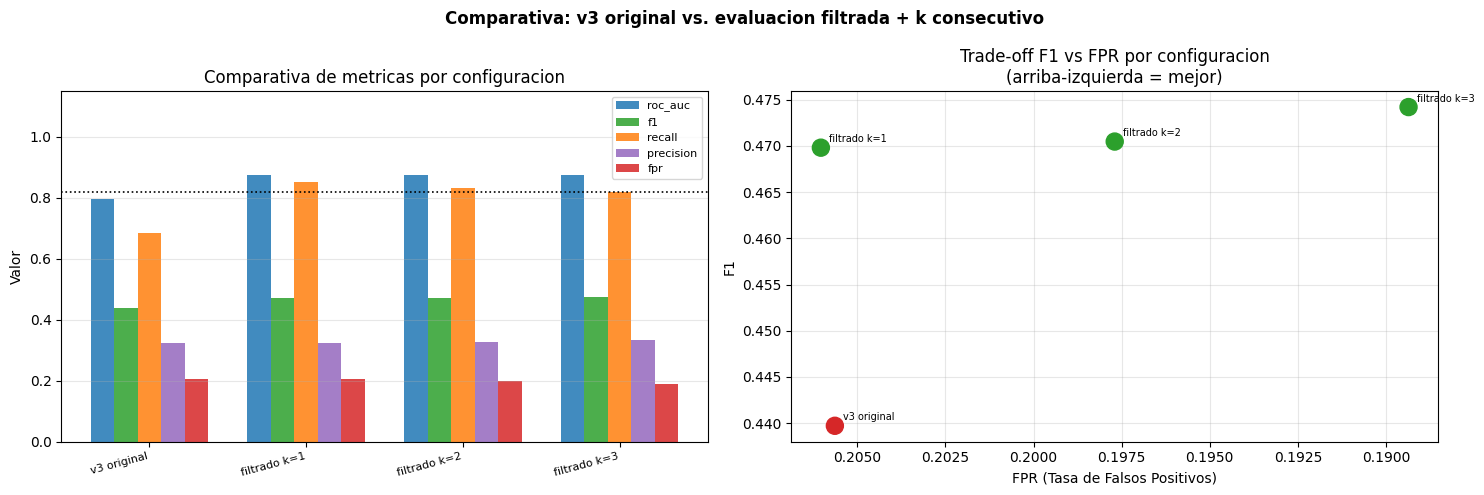

In [11]:
# ── Grafica comparativa de metricas ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

configs   = df_results['config'].tolist()
metrics_k = ['roc_auc','f1','recall','precision','fpr']
colors_m  = ['#1f77b4','#2ca02c','#ff7f0e','#9467bd','#d62728']
x = np.arange(len(configs))
width = 0.15

for i, (met, col) in enumerate(zip(metrics_k, colors_m)):
    vals = df_results[met].values
    bars = axes[0].bar(x + i*width, vals, width, label=met, color=col, alpha=0.85)

axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(configs, rotation=15, ha='right', fontsize=8)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Valor')
axes[0].set_title('Comparativa de metricas por configuracion')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(0.82, color='black', linestyle=':', lw=1.2, label='Ref 0.82')

# F1 vs FPR tradeoff
axes[1].scatter(df_results['fpr'], df_results['f1'],
                s=150, zorder=5,
                c=['#d62728'] + ['#2ca02c']*len(K_VALUES))
for _, row in df_results.iterrows():
    axes[1].annotate(row['config'], (row['fpr'], row['f1']),
                     textcoords='offset points', xytext=(6, 4), fontsize=7)
axes[1].set_xlabel('FPR (Tasa de Falsos Positivos)')
axes[1].set_ylabel('F1')
axes[1].set_title('Trade-off F1 vs FPR por configuracion\n(arriba-izquierda = mejor)')
axes[1].grid(True, alpha=0.3)
axes[1].invert_xaxis()

plt.suptitle('Comparativa: v3 original vs. evaluacion filtrada + k consecutivo',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(EVAL_DIR / 'comparativa_configuraciones.png'), dpi=130, bbox_inches='tight')
plt.show()


## 7. Curvas ROC y PR para la mejor configuracion filtrada

Mejor configuracion filtrada: k=3 | tau=0.2290
  F1=0.474 | Recall=0.818 | Precision=0.334 | FPR=0.189
  ROC-AUC=0.8751 | PR-AUC=0.3138


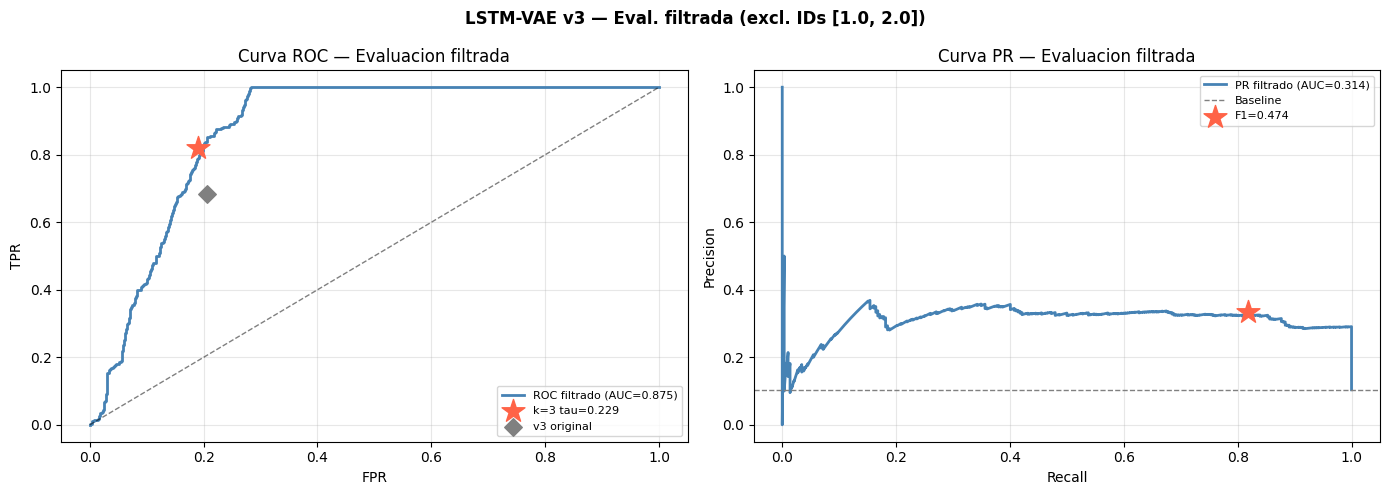

In [12]:
# Seleccionar la config filtrada con mejor F1
df_filt_results = df_results[df_results['excluidos'] != 'ninguno'].copy()
best_row        = df_filt_results.loc[df_filt_results['f1'].idxmax()]
BEST_K          = int(best_row['k'])
BEST_TAU        = float(best_row['tau'])

print(f'Mejor configuracion filtrada: k={BEST_K} | tau={BEST_TAU:.4f}')
print(f'  F1={best_row["f1"]:.3f} | Recall={best_row["recall"]:.3f} | '
      f'Precision={best_row["precision"]:.3f} | FPR={best_row["fpr"]:.3f}')
print(f'  ROC-AUC={best_row["roc_auc"]:.4f} | PR-AUC={best_row["pr_auc"]:.4f}')

fprs, tprs, _ = roc_curve(y_filt, sc_filt)
precs, recs, thrs_pr = precision_recall_curve(y_filt, sc_filt)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
axes[0].plot(fprs, tprs, color='steelblue', lw=2,
             label=f'ROC filtrado (AUC={best_row["roc_auc"]:.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
axes[0].scatter(best_row['fpr'], best_row['recall'],
                marker='*', s=300, color='tomato', zorder=5,
                label=f'k={BEST_K} tau={BEST_TAU:.3f}')
# Referencia v3 original
orig = df_results.iloc[0]
axes[0].scatter(orig['fpr'], orig['recall'],
                marker='D', s=80, color='gray', zorder=5, label='v3 original')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Curva ROC — Evaluacion filtrada')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# PR
axes[1].plot(recs, precs, color='steelblue', lw=2,
             label=f'PR filtrado (AUC={best_row["pr_auc"]:.3f})')
axes[1].axhline(y_filt.mean(), color='gray', linestyle='--', lw=1, label='Baseline')
axes[1].scatter(best_row['recall'], best_row['precision'],
                marker='*', s=300, color='tomato', zorder=5,
                label=f'F1={best_row["f1"]:.3f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Curva PR — Evaluacion filtrada')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.suptitle(f'LSTM-VAE v3 — Eval. filtrada (excl. IDs {EXCLUDED_ATTACK_IDS})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(EVAL_DIR / 'roc_pr_filtrado.png'), dpi=130, bbox_inches='tight')
plt.show()


## 8. Distribucion de scores y score temporal filtrados

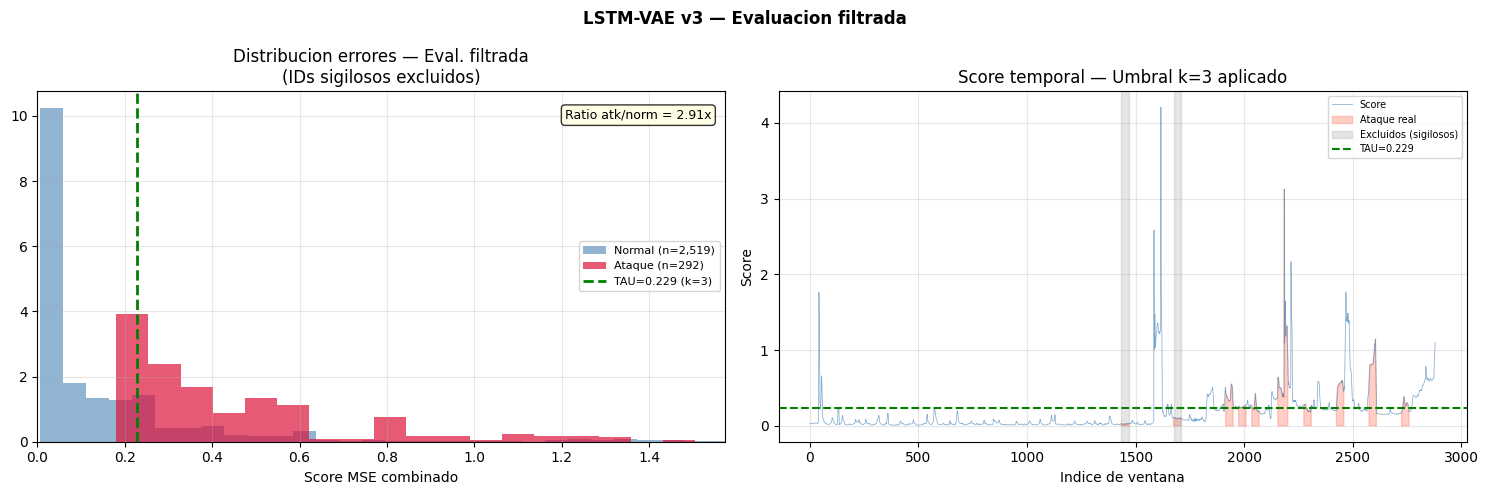

Ratio ataque/normal (filtrado): 2.91x


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribucion errores filtrada
sc_n = sc_filt[y_filt == 0]
sc_a = sc_filt[y_filt == 1]
axes[0].hist(sc_n, bins=80, alpha=0.6, density=True, color='steelblue',
             label=f'Normal (n={len(sc_n):,})')
axes[0].hist(sc_a, bins=40, alpha=0.7, density=True, color='crimson',
             label=f'Ataque (n={len(sc_a):,})')
axes[0].axvline(BEST_TAU, color='green', lw=2, linestyle='--',
                label=f'TAU={BEST_TAU:.3f} (k={BEST_K})')
axes[0].set_xlabel('Score MSE combinado')
axes[0].set_title('Distribucion errores — Eval. filtrada\n(IDs sigilosos excluidos)')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, np.percentile(sc_filt, 99.5))

ratio = sc_a.mean() / (sc_n.mean() + 1e-10)
axes[0].text(0.98, 0.95, f'Ratio atk/norm = {ratio:.2f}x',
             ha='right', va='top', transform=axes[0].transAxes,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8), fontsize=9)

# Score temporal con predicciones filtradas
t = np.arange(len(df_wins))
y_all = df_wins['y'].values
pred_best_full = consecutive_filter(scores, BEST_TAU, BEST_K)

axes[1].plot(t, scores, color='steelblue', lw=0.5, alpha=0.7, label='Score')
axes[1].fill_between(t, 0, scores, where=(y_all==1), color='tomato', alpha=0.3, label='Ataque real')
# Marcar ventanas excluidas en gris
excl_mask = (df_wins['y']==1) & (df_wins['attack_id'].isin(EXCLUDED_ATTACK_IDS))
axes[1].fill_between(t, 0, 1, where=excl_mask.values,
                     color='gray', alpha=0.2, transform=axes[1].get_xaxis_transform(),
                     label='Excluidos (sigilosos)')
axes[1].axhline(BEST_TAU, color='green', lw=1.5, linestyle='--', label=f'TAU={BEST_TAU:.3f}')
axes[1].set_xlabel('Indice de ventana'); axes[1].set_ylabel('Score')
axes[1].set_title(f'Score temporal — Umbral k={BEST_K} aplicado')
axes[1].legend(fontsize=7, loc='upper right'); axes[1].grid(True, alpha=0.3)

plt.suptitle('LSTM-VAE v3 — Evaluacion filtrada', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(EVAL_DIR / 'dist_y_temporal_filtrado.png'), dpi=130, bbox_inches='tight')
plt.show()
print(f'Ratio ataque/normal (filtrado): {ratio:.2f}x')


## 9. Resumen final y guardado de artefactos

Se guarda el config de la evaluacion filtrada como referencia para
la comparativa con datos sinteticos del TimeGAN.

In [14]:
print('=' * 65)
print('RESUMEN FINAL — LSTM-VAE v3 (Evaluacion filtrada)')
print('=' * 65)
print()
print(f'  Ataques excluidos    : IDs {EXCLUDED_ATTACK_IDS}')
print(f'  Razon                : Ataques fisicos sigilosos dentro del')
print(f'                         envelope estadistico normal. Indetectables')
print(f'                         con metodos de reconstruccion no supervisados.')
print()
print(f'  Filtro consecutivo   : k = {BEST_K} ventanas')
print(f'  Umbral optimo (tau)  : {BEST_TAU:.4f}')
print()
print(f'  --- METRICAS ORIGINALES (v3, todos los ataques, k=1) ---')
orig = df_results.iloc[0]
print(f'  ROC-AUC: {orig["roc_auc"]:.4f} | PR-AUC: {orig["pr_auc"]:.4f}')
print(f'  F1:      {orig["f1"]:.3f}  | Recall: {orig["recall"]:.3f}')
print(f'  Prec:    {orig["precision"]:.3f}  | FPR:    {orig["fpr"]:.3f}')
print()
print(f'  --- METRICAS FILTRADAS (excl. IDs {EXCLUDED_ATTACK_IDS}, k={BEST_K}) ---')
print(f'  ROC-AUC: {best_row["roc_auc"]:.4f} | PR-AUC: {best_row["pr_auc"]:.4f}')
print(f'  F1:      {best_row["f1"]:.3f}  | Recall: {best_row["recall"]:.3f}')
print(f'  Prec:    {best_row["precision"]:.3f}  | FPR:    {best_row["fpr"]:.3f}')
print(f'  TP={best_row["tp"]} | FP={best_row["fp"]} | FN={best_row["fn"]} | TN={best_row["tn"]}')
print('=' * 65)


RESUMEN FINAL — LSTM-VAE v3 (Evaluacion filtrada)

  Ataques excluidos    : IDs [1.0, 2.0]
  Razon                : Ataques fisicos sigilosos dentro del
                         envelope estadistico normal. Indetectables
                         con metodos de reconstruccion no supervisados.

  Filtro consecutivo   : k = 3 ventanas
  Umbral optimo (tau)  : 0.2290

  --- METRICAS ORIGINALES (v3, todos los ataques, k=1) ---
  ROC-AUC: 0.7963 | PR-AUC: 0.2930
  F1:      0.440  | Recall: 0.685
  Prec:    0.324  | FPR:    0.206

  --- METRICAS FILTRADAS (excl. IDs [1.0, 2.0], k=3) ---
  ROC-AUC: 0.8751 | PR-AUC: 0.3138
  F1:      0.474  | Recall: 0.818
  Prec:    0.334  | FPR:    0.189
  TP=239 | FP=477 | FN=53 | TN=2042


In [15]:
# Guardar tabla de resultados
df_results[cols_show].to_csv(EVAL_DIR / 'tabla_comparativa.csv', index=False)

# Guardar config de evaluacion filtrada
eval_config = {
    'version'               : 'lstm_vae_a12_v3_filtrado',
    'model_source'          : 'lstm_vae_a12_v3',
    'excluded_attack_ids'   : EXCLUDED_ATTACK_IDS,
    'exclusion_reason'      : (
        'Ataques fisicos sigilosos (Stage 5 Valve Manipulation ID1, '
        'Stage 1 Flow Disruption ID2). Scores sistematicamente por debajo '
        'de la media normal. Sensores objetivo con variabilidad equivalente '
        'en operacion normal. Indetectables con reconstruccion no supervisada.'
    ),
    'best_k'                : BEST_K,
    'best_tau'              : BEST_TAU,
    'alpha'                 : float(ALPHA),
    'window_size'           : WINDOW_SIZE,
    'stride'                : STRIDE,
    'n_attack_windows_eval' : int(y_filt.sum()),
    'n_normal_windows_eval' : int((y_filt==0).sum()),
    'metrics_original_v3'   : {
        'roc_auc'   : float(orig['roc_auc']),
        'pr_auc'    : float(orig['pr_auc']),
        'f1'        : float(orig['f1']),
        'recall'    : float(orig['recall']),
        'precision' : float(orig['precision']),
        'fpr'       : float(orig['fpr']),
    },
    'metrics_filtered'      : {
        'roc_auc'   : float(best_row['roc_auc']),
        'pr_auc'    : float(best_row['pr_auc']),
        'f1'        : float(best_row['f1']),
        'recall'    : float(best_row['recall']),
        'precision' : float(best_row['precision']),
        'fpr'       : float(best_row['fpr']),
    },
    'all_configs'           : df_results[cols_show].to_dict(orient='records'),
}

with open(EVAL_DIR / 'eval_filtrada_config.json', 'w') as f:
    json.dump(eval_config, f, indent=4)

print(f'Artefactos guardados en: {EVAL_DIR.resolve()}')
for fp in sorted(EVAL_DIR.iterdir()):
    print(f'  {fp.name}')


Artefactos guardados en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_vae_a12_v3\evaluacion_filtrada
  comparativa_configuraciones.png
  dist_y_temporal_filtrado.png
  eval_filtrada_config.json
  roc_pr_filtrado.png
  tabla_comparativa.csv
